In [9]:
import pandas as pd
import plotly.graph_objects as go
from datetime import datetime

# Load the datasets
m2_df = pd.read_csv('macro/fredData/m2.csv')
btc_df = pd.read_csv('micro/assetData/bitcoin.csv')

# Convert dates to datetime
m2_df['date'] = pd.to_datetime(m2_df['date'])
btc_df['date'] = pd.to_datetime(btc_df['date'])

# Filter M2 data to match Bitcoin's date range
m2_df = m2_df[m2_df['date'] >= btc_df['date'].min()]
m2_df = m2_df[m2_df['date'] <= btc_df['date'].max()]


m2_df['yoy'] = m2_df['m2'].pct_change(periods=12) * 100

# Calculate variations for Bitcoin (using price column)

btc_df['yoy'] = btc_df.iloc[:, 1].pct_change(periods=365) * 100

# Create dual-axis YoY comparison plot
fig_yoy = go.Figure()
fig_yoy.add_trace(go.Scatter(x=m2_df['date'], y=m2_df['yoy'], name='M2 YoY', line=dict(color='blue')))
fig_yoy.add_trace(go.Scatter(x=btc_df['date'], y=btc_df['yoy'], name='Bitcoin YoY', 
                            line=dict(color='orange'), yaxis='y2'))
fig_yoy.update_layout(
    title='Year-over-Year Variations: M2 vs Bitcoin',
    xaxis_title='Date',
    yaxis_title='M2 Variation (%)',
    yaxis2=dict(title='Bitcoin Variation (%)', overlaying='y', side='right'),
    legend=dict(x=1.1, y=1)
)


fig_yoy.show()

In [11]:
import requests

url = "https://api.db.nomics.world/v22/series/ISM/pmi?facets=1&format=json&limit=1000&observations=1"
response = requests.get(url)
data = response.json()
print(data)

{'_meta': {'args': {'align_periods': False, 'dataset_code': 'pmi', 'dimensions': {}, 'facets': True, 'format': 'json', 'limit': 1000, 'metadata': True, 'observations': True, 'offset': 0, 'provider_code': 'ISM', 'q': '', 'series_code': None}, 'version': '22.1.17'}, 'dataset': {'code': 'pmi', 'dimensions_codes_order': ['frequency'], 'dimensions_labels': {'frequency': 'Frequency'}, 'dimensions_values_labels': {'frequency': {'M': 'Monthly'}}, 'dir_hash': '281b1f57e08e66f2d02fc328fd53df175a005d2f', 'indexed_at': '2025-01-05T02:13:19.536Z', 'name': 'Manufacturing - PMI', 'nb_series': 1, 'next_release_at': '2025-02-03', 'provider_code': 'ISM', 'provider_name': 'Institute for Supply Management'}, 'errors': None, 'provider': {'code': 'ISM', 'indexed_at': '2025-02-03T03:04:34.394Z', 'name': 'Institute for Supply Management', 'region': 'US', 'slug': 'ism', 'terms_of_use': 'https://www.ismworld.org/footer/terms-of-use/', 'website': 'https://www.ismworld.org'}, 'series': {'docs': [{'@frequency': 'm

In [16]:
import requests
import pandas as pd

def parse_pmi_json(json_data):
    """
    Parses PMI data from the given JSON.
    """
    try:
        # 'json_data' is already a Python dictionary, so we can just extract from it
        series_data = json_data["series"]["docs"][0]

        periods = series_data["period"]  # List of time periods (monthly)
        values = series_data["value"]    # Corresponding PMI values

        # Create a DataFrame
        df = pd.DataFrame({
            "Date": pd.to_datetime(periods),
            "PMI": values
        })

        df.sort_values("Date", inplace=True)  # Ensure chronological order
        df.set_index("Date", inplace=True)    # Set Date as index
        return df
    except Exception as e:
        print(f"Error parsing JSON: {e}")
        return None

if __name__ == "__main__":
    url = "https://api.db.nomics.world/v22/series/ISM/pmi?facets=1&format=json&limit=1000&observations=1"
    response = requests.get(url)
    data = response.json()

    # Parse the JSON into a DataFrame
    df_pmi = parse_pmi_json(data)

    if df_pmi is not None:
        print(df_pmi)


             PMI
Date            
2020-05-01  43.1
2020-06-01  52.2
2020-07-01  53.7
2020-08-01  55.6
2020-09-01  55.7
2020-10-01  58.8
2020-11-01  57.7
2020-12-01  60.5
2021-01-01  58.7
2021-02-01  60.9
2021-03-01  63.7
2021-04-01  60.6
2021-05-01  61.6
2021-06-01  60.9
2021-07-01  59.9
2021-08-01  59.7
2021-09-01  60.5
2021-10-01  60.8
2021-11-01  60.6
2021-12-01  58.8
2022-01-01  57.6
2022-02-01  58.4
2022-03-01  57.0
2022-04-01  55.9
2022-05-01  56.1
2022-06-01  53.1
2022-07-01  52.7
2022-08-01  52.9
2022-09-01  51.0
2022-10-01  50.0
2022-11-01  49.0
2022-12-01  48.4
2023-01-01  47.4
2023-02-01  47.7
2023-03-01  46.5
2023-04-01  47.0
2023-05-01  46.6
2023-06-01  46.4
2023-07-01  46.5
2023-08-01  47.6
2023-09-01  48.6
2023-10-01  46.9
2023-11-01  46.6
2023-12-01  47.1
2024-01-01  49.1
2024-02-01  47.8
2024-03-01  50.3
2024-04-01  49.2
2024-05-01  48.7
2024-06-01  48.5
2024-07-01  46.8
2024-08-01  47.2
2024-09-01  47.2
2024-10-01  46.5
2024-11-01  48.4
2024-12-01  49.3


In [3]:
import yfinance as yf

# Define the ticker for the US Dollar Index
ticker = "DX-Y.NYB"

# Create a Ticker object
dxy = yf.Ticker(ticker)

# Get the historical market data; 'max' retrieves all available data
dxy_data = dxy.history(period="max")

# Display the first few rows of the data
print(dxy_data.head())


                                 Open        High         Low       Close  \
Date                                                                        
1971-01-04 00:00:00-05:00  120.529999  120.529999  120.529999  120.529999   
1971-01-05 00:00:00-05:00  120.519997  120.519997  120.519997  120.519997   
1971-01-06 00:00:00-05:00  120.489998  120.489998  120.489998  120.489998   
1971-01-07 00:00:00-05:00  120.550003  120.550003  120.550003  120.550003   
1971-01-08 00:00:00-05:00  120.529999  120.529999  120.529999  120.529999   

                           Volume  Dividends  Stock Splits  
Date                                                        
1971-01-04 00:00:00-05:00       0        0.0           0.0  
1971-01-05 00:00:00-05:00       0        0.0           0.0  
1971-01-06 00:00:00-05:00       0        0.0           0.0  
1971-01-07 00:00:00-05:00       0        0.0           0.0  
1971-01-08 00:00:00-05:00       0        0.0           0.0  


In [4]:
print(dxy_data.tail())

                                 Open        High         Low       Close  \
Date                                                                        
2025-02-03 00:00:00-05:00  108.500000  109.879997  108.339996  108.989998   
2025-02-04 00:00:00-05:00  108.680000  109.040001  107.919998  107.959999   
2025-02-05 00:00:00-05:00  108.010002  108.010002  107.300003  107.580002   
2025-02-06 00:00:00-05:00  107.620003  108.099998  107.540001  107.690002   
2025-02-07 00:00:00-05:00  107.698997  108.022003  107.515999  107.664001   

                           Volume  Dividends  Stock Splits  
Date                                                        
2025-02-03 00:00:00-05:00       0        0.0           0.0  
2025-02-04 00:00:00-05:00       0        0.0           0.0  
2025-02-05 00:00:00-05:00       0        0.0           0.0  
2025-02-06 00:00:00-05:00       0        0.0           0.0  
2025-02-07 00:00:00-05:00       0        0.0           0.0  


In [5]:
import os
import pandas as pd
import plotly.graph_objects as go

# Define the path to the CSV file (adjust if necessary)
csv_path = os.path.join("macro", "fredData", "yieldCurveRegime.csv")
try:
    df = pd.read_csv(csv_path)
except Exception as e:
    print(f"Error loading CSV file from {csv_path}: {e}")
    exit()

# Convert the 'date' column to datetime format
df['date'] = pd.to_datetime(df['date'])

# Define a test date range (adjust as needed)
start_date = pd.to_datetime("1976-06-29")
end_date   = pd.to_datetime("2025-01-01")

# Filter the DataFrame by the date range and reset its index


# Create the base figure that plots the spread as a black line.
fig = go.Figure()

# Base spread line trace
fig.add_trace(go.Scatter(
    x=df['date'],
    y=df['spread'],
    mode='lines',
    name='Spread',
    line=dict(color='black', width=2)
))

# -------------------------------------------------------------------
# Group the data into contiguous blocks based on the regime value.
# -------------------------------------------------------------------
blocks = []
current_regime = df.loc[0, 'regime']
current_color = df.loc[0, 'color']
start_idx = 0

for i in range(1, len(df)):
    regime = df.loc[i, 'regime']
    if regime != current_regime:
        # Save the block of contiguous rows with the current regime.
        blocks.append((start_idx, i - 1, current_regime, current_color))
        start_idx = i
        current_regime = regime
        current_color = df.loc[i, 'color']

# Append the final block.
blocks.append((start_idx, len(df) - 1, current_regime, current_color))

# -------------------------------------------------------------------
# For each contiguous regime block, overlay an area plot.
# The area plot uses the same spread values, but the fill is
# color coded based on the regime.
# -------------------------------------------------------------------
for block in blocks:
    s_idx, e_idx, block_regime, block_color = block
    block_data = df.iloc[s_idx:e_idx+1]
    fig.add_trace(go.Scatter(
        x = block_data['date'],
        y = block_data['spread'],
        mode = 'lines',
        name = f"{block_regime} area",
        line = dict(width=0),  # hide line details for the area trace
        fill = 'tozeroy',       # fill from the line to y=0
        fillcolor = block_color,  # using the hex color from the CSV
        opacity = 0.3,
        showlegend = False,
        hoverinfo = 'skip'
    ))

# Update the layout of the figure.
fig.update_layout(
    title="2-10 Year Treasury Spread with Regime Color-Coded Area Overlay",
    xaxis_title="Date",
    yaxis_title="Spread",
    template="plotly_white",
)

# Show the figure (this works in a Jupyter Notebook environment)
fig.show()


Summary Statistics:
            regime  cum_return  volatility  days
0   bear_flattener       -3.39       75.38   523
1   bear_steepener      -11.17       66.35   653
2   bull_flattener      547.20       63.91   590
3   bull_steepener      234.63       76.78   351
4  flattener_twist      263.17       68.15   201
5          neutral      -34.96       69.76   285
6  steepener_twist      123.93       80.70   353


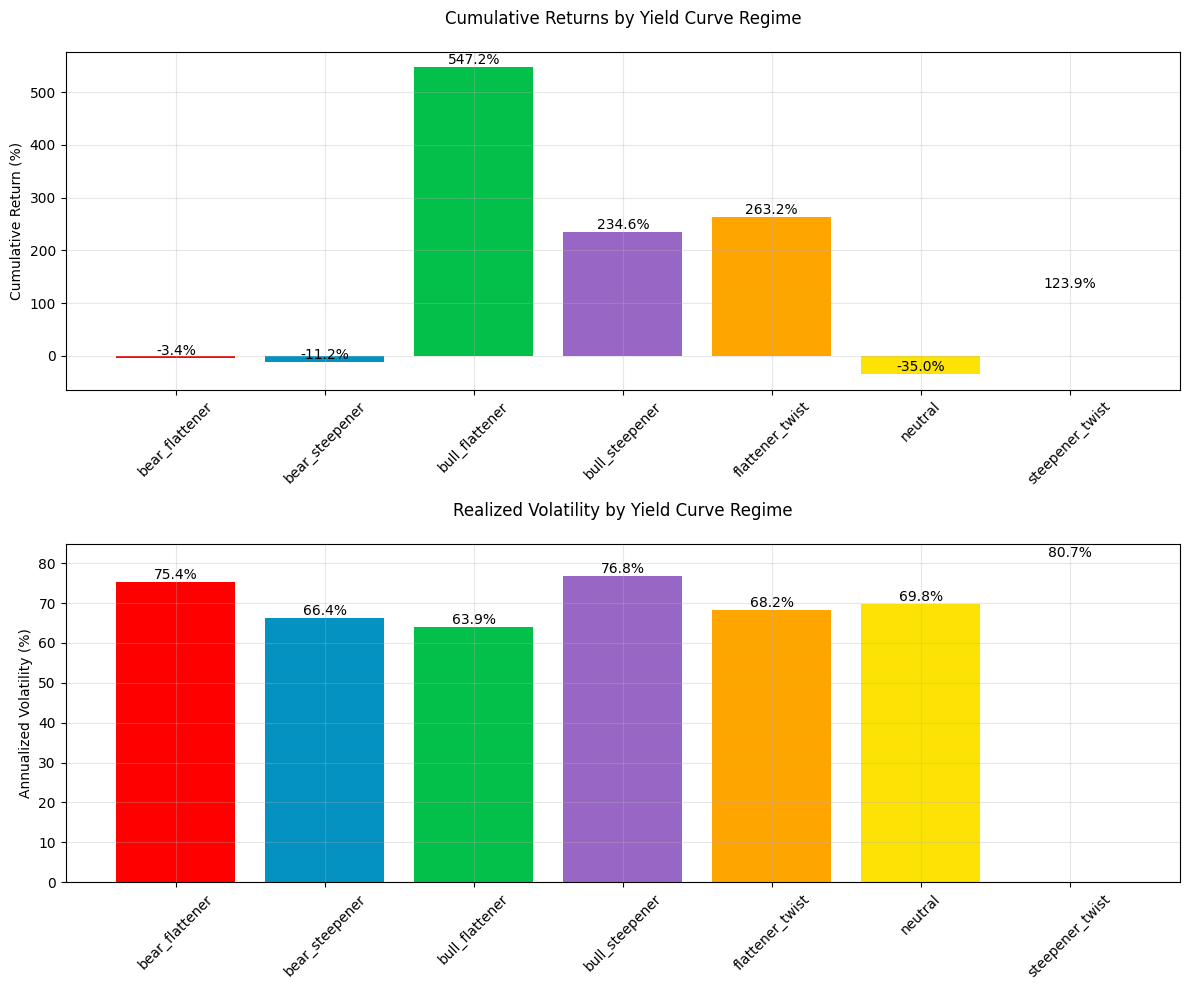

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load the data
def load_data():
    yield_curve = pd.read_csv('macro/fredData/yieldCurveRegime.csv', parse_dates=[0])
    btc = pd.read_csv('micro/candleData/bitcoin_candles.csv', parse_dates=[0])
    
    # Set dates as index
    yield_curve.set_index('date', inplace=True)
    btc.set_index('date', inplace=True)
    
    # Filter BTC data from 2017 onwards
    #btc = btc[btc.index >= '2017-01-01']
    
    # Filter yield curve data to match Bitcoin's date range
    yield_curve = yield_curve[yield_curve.index >= '2017-01-01']
    
    return yield_curve, btc

def calculate_metrics(yield_curve, btc):
    # Calculate daily returns based on close prices (assumed to be in the fourth column)
    btc['returns'] = btc.iloc[:, 3].pct_change()

    # Reset indices for merging operations
    btc_reset = btc.reset_index()
    yield_curve_reset = yield_curve.reset_index()

    # Merge BTC data with yield curve regime information using merge_asof.
    # This ensures every BTC day gets the most recent regime info from the yield curve,
    # so that the last available regime persists over gaps (e.g., weekends, holidays).
    merged_df = pd.merge_asof(
        btc_reset.sort_values('date'),
        yield_curve_reset.sort_values('date')[['date', 'regime']],
        on='date',
        direction='backward'
    )

    # Initialize results dictionary
    results = {
        'regime': [],
        'cum_return': [],
        'volatility': [],
        'days': []
    }

    # Group the merged data by regime and calculate metrics
    for regime, group in merged_df.groupby('regime'):
        if group.empty:
            continue

        # Calculate cumulative return for the regime
        cum_return = (1 + group['returns']).prod() - 1
        # Calculate realized volatility from daily returns and annualize by 365 (24/7 market)
        volatility = np.std(group['returns']) * np.sqrt(365)

        results['regime'].append(regime)
        results['cum_return'].append(cum_return * 100)  # Convert to percentage
        results['volatility'].append(volatility * 100)    # Convert to percentage
        results['days'].append(len(group))

    return pd.DataFrame(results)

def plot_results(results):
    # Use a basic matplotlib style instead of seaborn
    plt.style.use('default')
    
    # Create figure with two subplots
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10))
    
    # Plot cumulative returns
    colors = ['#FF0000', '#0492C2', '#03C04A', '#9867C5', '#FFA500', '#FCE205', '#FFFFFF']
    bars1 = ax1.bar(results['regime'], results['cum_return'], color=colors)
    ax1.set_title('Cumulative Returns by Yield Curve Regime', pad=20)
    ax1.set_ylabel('Cumulative Return (%)')
    ax1.tick_params(axis='x', rotation=45)
    ax1.grid(True, alpha=0.3)
    
    # Add value labels
    for bar in bars1:
        height = bar.get_height()
        ax1.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.1f}%', ha='center', va='bottom')
    
    # Plot volatility
    bars2 = ax2.bar(results['regime'], results['volatility'], color=colors)
    ax2.set_title('Realized Volatility by Yield Curve Regime', pad=20)
    ax2.set_ylabel('Annualized Volatility (%)')
    ax2.tick_params(axis='x', rotation=45)
    ax2.grid(True, alpha=0.3)
    
    # Add value labels
    for bar in bars2:
        height = bar.get_height()
        ax2.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.1f}%', ha='center', va='bottom')
    
    plt.tight_layout()
    plt.show()  # Just show the plot instead of saving it


# ... rest of the code remains the same ...

def main():
    # Load data
    yield_curve, btc = load_data()
    
    # Calculate metrics
    results = calculate_metrics(yield_curve, btc)
    
    # Print summary statistics
    print("\nSummary Statistics:")
    print(results.round(2))
    
    # Plot results
    plot_results(results)

if __name__ == "__main__":
    main()